In [95]:
import numpy as np 
import pandas as pd 
from sklearn.datasets import make_classification

In [ ]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [97]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.090268,-2.417356,0.228217,-0.976866,-1.060847,0
1,-1.773483,0.737449,1.657632,1.124880,0.468831,1
2,-2.069926,-0.652730,0.640889,0.115541,-0.020770,1
3,-1.331608,2.138190,-1.431574,1.754734,2.423573,1
4,-0.376709,-0.223019,0.421409,0.126212,0.268424,0


Function for Rows sampling 

In [98]:
def sample_rows(df,percent, replace = True):
    return df.sample(int(percent*df.shape[0]))

Function for Features sampling 

In [99]:
def sample_features(df,percent):
    cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
    return df[cols]

Function for combined sampling 

In [100]:
def combined_sampling(df,row_percent,col_percent):
    new_df = sample_rows(df,row_percent)
    return sample_features(new_df,col_percent)

Now make Three datasets for 3 tree

In [101]:
df1 = sample_rows(df, 0.1)
df1

,col1,col2,col3,col4,col5,target
77,-0.530814,0.077673,-0.691855,1.245344,0.301314,1
62,-1.839115,1.226204,-0.902329,-1.313048,1.717624,0
89,-2.423768,-1.659308,1.578285,0.442097,-0.078724,1
32,-1.356179,-2.558423,-1.054924,-1.554321,1.684318,0
4,-0.376709,-0.223019,0.421409,0.126212,0.268424,0
0,-0.090268,-2.417356,0.228217,-0.976866,-1.060847,0
40,-1.699028,1.829607,2.586840,-1.734461,0.344800,0
93,-1.666225,0.522002,0.072871,2.603865,1.163602,1
85,-2.007856,2.450816,0.196444,3.723132,2.818891,1
36,-0.385788,1.407308,-1.592263,1.242102,1.103818,1


In [102]:
df2 = sample_rows(df, 0.1)
df2

,col1,col2,col3,col4,col5,target
51,-1.107821,2.727093,-1.734886,2.040054,1.726965,1
74,-0.236802,-0.109838,-1.440396,-0.327460,-0.124505,1
79,-0.621692,1.196121,-1.485767,1.235777,0.901444,1
99,-2.509662,-0.274035,1.636175,-2.286149,0.078361,0
64,-0.635480,-2.726229,-0.438800,-1.242490,-2.361977,0
94,-0.630221,-1.684325,0.655837,-0.728747,-2.307789,0
68,-2.459412,-2.507703,1.083072,-1.696000,-3.361443,0
41,-2.346797,-0.625769,1.832188,-1.523243,-1.350087,0
67,-1.590361,1.466222,-1.293891,0.505084,1.296281,1
91,-2.526892,-3.348010,0.822437,-2.333590,-4.477722,0


In [103]:
df3 = sample_rows(df, 0.1)
df3

,col1,col2,col3,col4,col5,target
69,-3.319194,-0.607674,0.284214,-1.416557,-0.634414,0
49,-0.039466,2.630438,-2.200802,1.315664,1.288909,1
75,1.340604,-1.212371,3.185723,2.240499,-3.463902,0
36,-0.385788,1.407308,-1.592263,1.242102,1.103818,1
54,-1.101503,0.439826,-0.288506,0.666579,0.043132,1
81,-2.932660,1.985594,2.510189,4.404443,2.937904,1
68,-2.459412,-2.507703,1.083072,-1.696000,-3.361443,0
23,-0.563765,1.857128,-1.849508,0.968090,1.669917,1
17,-3.061647,1.029408,2.465036,1.102829,0.107003,1
43,-1.664117,-2.433027,0.735520,-2.659396,-1.443331,0


In [104]:
df1.shape

(10, 6)

In [105]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='object')
Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='object')
Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='object')


In [106]:
from sklearn.tree import DecisionTreeClassifier 
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [107]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.75, 'x[3] <= 0.284\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.625, 0.5, '  False')]

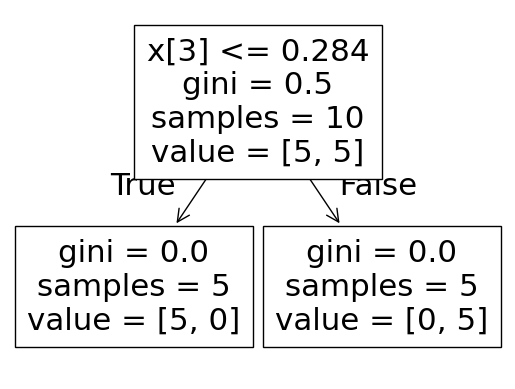

In [108]:
from sklearn.tree import plot_tree 
plot_tree(clf1)

[Text(0.5, 0.75, 'x[1] <= -0.192\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.625, 0.5, '  False')]

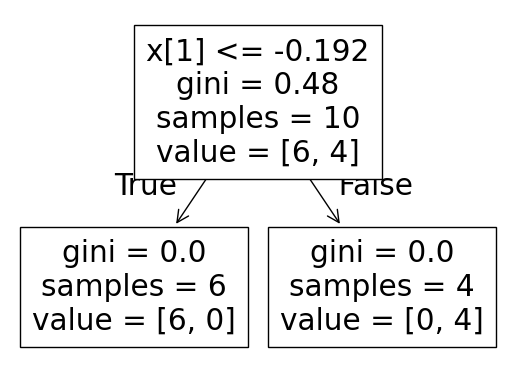

In [109]:
plot_tree(clf2)

[Text(0.5, 0.75, 'x[4] <= -0.296\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.625, 0.5, '  False')]

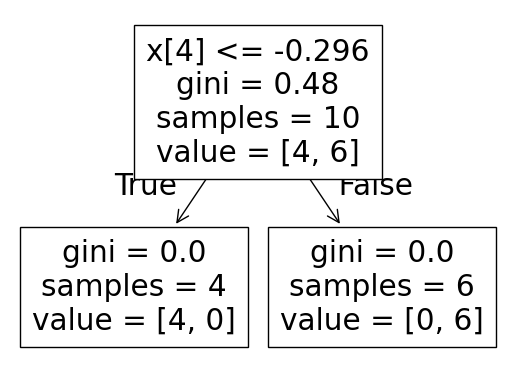

In [110]:
plot_tree(clf3)

In [111]:
clf1.predict(np.array([0.610294,2.198901,-1.809750,2.763093,2.362812]).reshape(1,5))

c:\Users\Mr.user\anaconda3\envs\ml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [112]:
clf2.predict(np.array([0.610294,2.198901,-1.809750,2.763093,2.362812]).reshape(1,5))

c:\Users\Mr.user\anaconda3\envs\ml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [113]:
clf3.predict(np.array([0.610294,2.198901,-1.809750,2.763093,2.362812]).reshape(1,5))

c:\Users\Mr.user\anaconda3\envs\ml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

Majority is 0 then answer is 0

In [114]:
clf1.predict(np.array([-1.773483,0.737449,1.657632,1.124880, 0.468831]).reshape(1,5))

c:\Users\Mr.user\anaconda3\envs\ml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [115]:
clf2.predict(np.array([-1.773483, 0.737449,	1.657632,	1.124880,	0.468831]).reshape(1,5))

c:\Users\Mr.user\anaconda3\envs\ml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [116]:
clf3.predict(np.array([-1.773483,	0.737449,	1.657632,	1.124880,	0.468831]).reshape(1,5))

c:\Users\Mr.user\anaconda3\envs\ml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

Majority is 1 then Answer is also 1 -->correct answer 